In [3]:
import random
import json
import os, sys
from importlib import reload
from pathlib import Path
import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer

random.seed(6)
np.random.seed(6)

hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")


Disabling PyTorch because PyTorch >= 2.1 is required but found 2.0.1
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [4]:
# My modules

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import (
    response_processing as rp,
    video_tools)

from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz


In [5]:
# Files
STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

#VQA_RESP = WORK_DIR / "outputs/vqa_video_fps_gemma3:4b-it-qat_20250629_16:44:00.jsonl"

SGG_GRAPHS = WORK_DIR / "scripts/data/sgg_gemini2.5flash_1000_20250824_20:00:00_aggregated.jsonl"
GT_SGG_GRAPHS = WORK_DIR / "data/datasets/STAR_verbalized_stsg_val.json"

#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250825_18:30:00.jsonl"
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250826_18:30:00.jsonl"
GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250828_17:48:00.jsonl"

# on the 200 sub-set
#SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_200_20250804_19:21:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")

prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]

SHOW_VIDEO = False


# Experiment

# Prompts

### VQA

In [6]:
with open(WORK_DIR / 'data/prompts/vqa/user_prompt.txt', 'r') as f:
    pr = f.read()

print(pr)


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video and a question. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by

In [7]:
with open(WORK_DIR / 'data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt', 'r') as f:
    pr = f.read()

print(pr)


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



### SGG

In [8]:
with open(WORK_DIR / "data/prompts/graph-gen/user_prompt_v2.txt") as f:
    pr = f.read()
    
print(pr)
    


You are an intelligent video comprehension model and are going to receive as input a sequence of images extracted from a video. You need to analyze and describe the scene unfolding in the video (sequence of frames) following these guidelines:
1. Look for recurring objects;
2. Note that the same object may appear differently across frames due to low image quality, varying viewing angles, or partial obstructions. Carefully check objects with similar features (e.g. shape, color), appearing in different frames, as they may still be the same object;
3. Pay attention to how the person interacts with its environment
4. Understand the directional movement of the people and objects in the video
5. Carefully analyze the chronological sequence of the events occurring in the video;
6. Pay attention to the atomic and fine grained movement, pose and actions of the people in the video. Compose these atomic actions happening across the frame to infer the higher level action performed by the person;
7.

In [9]:
with open(WORK_DIR / "data/prompts/graph-gen/format_instructions_v2corrected.txt") as f:
    pr = f.read()
    
print(pr)
    


Now organize the objects and relationships you identified before into a formal spatio-temporal scene graph using this format for the predicates: 
object1 ---- relationship ---- object2

The spatio-temporal scene graph should be enclosed between the tags <stsg> and </stsg>.
The list of relationship predicates pertaining a frame should be introduced by the frame ID or name and enclosed in the tags <scene_graph> and </scene_graph>:


For example:
<stsg>
Frame 0:
<scene_graph>
man ----  sitting_on ---- chair
dog ---- lying_under ----  table
book ---- on_top_of ---- shelf
woman ---- on_the_right_of ---- man
... 
</scene_graph>

Frame 1:
<scene_graph>
woman ---- on_the_left_of ---- man
...
</scene_graph>
</stsg>


Please follow these guidelines:
1. Create an appropriate number of relationship triplets (more if the image is complex)
2. Use specific and consistent object labels
3. Use concise but descriptive relationship terms (connect words with underscores)
4. Include all meaningful relation

### Graph understanding from the SGG

In [10]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_system_prompt_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


You need to respond to reasoning questions by making logical inference on sequence of Scene-Graphs extracted from frames belonging to a video, called a Spatio-Temporal Scene Graph.

IMPORTANT CLARIFICATIONS:
- You will receive a question and Spatio-Temporal Scene-Graph
- Each Scene-Graph is a static symbolic representation of the scene unfolding in the frame
- The Scene-Graphs are ordered chronologically
- The Scene-Graph is represented as a set of tuple in the format: subject - relationship - object
- The Spatio-Temporal Scene-Graph is a cornologically sorted list of Scene-Graphs

INSTRUCTIONS:
- Read the entire Spatio-Temporal Scene-Graphs in chronological order and pay attention at the order of how events unfold.
- Read the question and reason about the answer step by step.
- In your answer include key events or relationships that help you in determing the correct answer.
- Be careful to reproduce the chosen alternative as it is presented.


In [11]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/MCQ_user_prompt_ZS_CoT_v3.txt") as f:
    pr = f.read()
    
print(pr)
    


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
{stsg}
</STSG>

Given the following question:
<Q>
{question}
<Q>

And the following alternatives:
<Alternatives>
A. {c1}
B. {c2}
C. {c3}
D. {c4}
</Alternatives>

Provide an answer to the above question reasoning step by step on the Spatio-Temporal Scene-Graph (STSG) and choosing one of the alternatives. 

In answering the question please be sure to operate according to the following guidlines:
1. Question Interpretation: Clearly state what the question is asking
2. STSG Analysis: Carefully examine the spatial and temporal relationships in the scene graph
3. Alternative Evaluation: For each option (A, B, C, D), explain whether it matches the STSG evidence
4. Reasoning: Provide clear logical step by step reasoning leading to your conclusion
5. Conclusion: Declare the logical conclusion to your reasoning in the above step
6. Consistency Check: B

In [12]:
with open(WORK_DIR / "data/prompts/zero-shot-cot/auto_reply_ZS_CoT.txt") as f:
    pr = f.read()
    
print(pr)
    


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



# Loading GT

Let's load the ground truth from the `STAR_QA_question_and_stsg_val.json` file where we extracted QA and spatio-temporal scene graphs

In [13]:
with open(STAR_VAL_SMALL) as f:
    ground_truth = json.load(f)


gt_df = pd.DataFrame(ground_truth).astype({'question_id': 'string', 'answer': 'string'})
gt_df.rename(columns={"question_id": "id", "answer": "text"}, inplace=True)
gt_df.set_index('id', inplace=True)
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   string 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(5), string(1)
memory usage: 73.7+ KB


# Loading Scene Graphs

In [14]:
sgg_df = pd.read_json(SGG_GRAPHS, lines=True)
sgg_df = sgg_df.set_index("question_id")
sgg_df


,key,request,response_x,response_y,stsg
question_id,,,,,
Feasibility_T5_102,Feasibility_T5_102,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'candidates': [{'index': 0, 'content': {'part...","{'modelVersion': 'gemini-2.5-flash', 'usageMet...",<stsg>\nFrame 0:\n<scene_graph>\nperson ---- w...
Feasibility_T2_860,Feasibility_T2_860,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'usageMetadata': {'promptTokenCount': 2366, '...","{'candidates': [{'index': 0, 'finishReason': '...",<stsg>\nFrame 0:\n<scene_graph>\nperson ---- i...
Prediction_T1_2539,Prediction_T1_2539,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'modelVersion': 'gemini-2.5-flash', 'usageMet...","{'responseId': 'I2GraNTdH-PWjMcPs5uL6Q8', 'can...",<stsg>\nFrame 0:\n<scene_graph>\nwoman_in_fore...
Prediction_T4_1253,Prediction_T4_1253,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'responseId': '1luraP_lO6uNjMcPh86i2Q8', 'can...","{'responseId': 'I2GraKb1Os70jMcPtI6WmQY', 'usa...",<stsg>\nFrame 0:\n<scene_graph>\nman ---- in -...
Interaction_T1_5612,Interaction_T1_5612,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'modelVersion': 'gemini-2.5-flash', 'response...","{'modelVersion': 'gemini-2.5-flash', 'response...",<stsg>\nFrame 0:\n<scene_graph>\nboy_striped_s...
...,...,...,...,...,...
Interaction_T1_8913,Interaction_T1_8913,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'responseId': 'll2raKjNOLmOjMcPmaeq8Qk', 'usa...",{'usageMetadata': {'candidatesTokenCount': 634...,<stsg>\nFrame 0:\n<scene_graph>\nman ---- in_r...
Interaction_T1_8967,Interaction_T1_8967,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'candidates': [{'content': {'role': 'model', ...","{'modelVersion': 'gemini-2.5-flash', 'response...",<stsg>\nFrame 0:\n<scene_graph>\nwoman ---- st...
Interaction_T2_1847,Interaction_T2_1847,"{'contents': [{'role': 'user', 'parts': [{'tex...","{'responseId': 'll2raIycK6HmjMcPsLi58A8', 'usa...","{'modelVersion': 'gemini-2.5-flash', 'candidat...",<stsg>\nFrame 0:\n<scene_graph>\nperson ---- m...


In [15]:
print(sgg_df.iloc[0]['request']['contents'][3]['parts'][0]['text'])


<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
black_garment ---- has_markings ---- "99"
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
person ---- moving ---- black_garment_upwards
person ---- guiding_arm_through ---- black_garment_sleeve
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 2:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- putting_

In [16]:
print(sgg_df.iloc[0]['stsg'])


<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
black_garment ---- has_markings ---- "99"
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
person ---- moving ---- black_garment_upwards
person ---- guiding_arm_through ---- black_garment_sleeve
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 2:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- putting_

In [17]:
gt_sgg_df = pd.read_json(GT_SGG_GRAPHS)
gt_sgg_df = gt_sgg_df.set_index("question_id")
gt_sgg_df


,video_id,start,end,stsg
question_id,,,,
Interaction_T1_13,6H78U,11.1,19.6,Frame 000198\n\tperson --- on_the_side_of --- ...
Interaction_T1_14,6H78U,15.6,22.7,Frame 000286\n\tperson --- holding --- towel\n...
Interaction_T1_31,RNLTR,7.3,13.5,Frame 000132\n\tperson --- wearing --- clothes...
Interaction_T1_32,RNLTR,11.6,16.4,Frame 000194\n\tperson --- on_the_side_of --- ...
Interaction_T1_40,VNQTH,2.7,9.2,Frame 000043\n\tperson --- holding --- clothes...
...,...,...,...,...
Feasibility_T6_1453,L9ANI,7.3,12.9,Frame 000227\n\tperson --- on_the_side_of --- ...
Feasibility_T6_1454,L9ANI,0.0,4.1,Frame 000013\n\tperson --- in_front_of --- tab...
Feasibility_T6_1455,L9ANI,0.0,4.1,Frame 000013\n\tperson --- in_front_of --- tab...


# Loading predicted answers evaluation

In [18]:
with GEMINI_RESPONSES_FPATH.open('r') as f:
    data = [json.loads(line) for line in f.readlines()]
    
data[0]


{'key': 'Feasibility_T5_102',
 'request': {'contents': [{'role': 'user',
    'parts': [{'text': 'Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:\n\n<STSG>\n<stsg>\nFrame 0:\n<scene_graph>\nperson ---- wearing ---- teal_tank_top\nperson ---- wearing ---- dark_pants\nperson ---- in_front_of ---- open_closet\nperson ---- holding ---- black_garment\nblack_garment ---- has_markings ---- "99"\nopen_closet ---- contains ---- hanging_clothes\nopen_closet ---- contains ---- laundry_hamper\nlaundry_hamper ---- on_the_floor_inside ---- open_closet\n</scene_graph>\n\nFrame 1:\n<scene_graph>\nperson ---- wearing ---- teal_tank_top\nperson ---- wearing ---- dark_pants\nperson ---- in_front_of ---- open_closet\nperson ---- holding ---- black_garment\nperson ---- moving ---- black_garment_upwards\nperson ---- guiding_arm_through ---- black_garment_sleeve\nopen_closet ---- contains ---- hanging_clothes\nopen_close

In [19]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: { "answer": "The provided Spatio-Temporal Scene Graph details the woman sweeping with a broom from Frame 0 to Frame 15. Subsequently, in Frame 16, she stands up from sweeping and turns towards the kitchen counter. From Frame 17 to Frame 20, she walks towards the kitchen counter, reaches it, bends down, and is described as "interacting_with ---- counter_area" and "engaged_with ---- items_on_counter". While the STSG clearly shows her interacting with the counter area after using the broom, it does not specify what these "items on counter" were. None of the alternatives (A. The sandwich, B. The dish, C. The book, D. The picture) are explicitly mentioned in the scene graph. Therefore, based on a strict interpretation of the

Total answers: 1032
Answers following JSON template: 1031
Percentage following JSON template: 99.90%
Answer with a valid alternative: 916
88.85% of the total

Invalid answers: 115
Total answers: 1031
Answers following JSON template: 1030
Percentage following JSON template: 99.90%
Answer with a valid alternative: 885
85.92% of the total

Invalid answers: 145


/home/lusha/star_code/src/response_processing.py:187: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


### Gemini sanity-check

#### Sample question

In [20]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][0]["content"])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
black_garment ---- has_markings ---- "99"
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
person ---- moving ---- black_garment_upwards
person ---- guiding_arm_through ---- black_garment_sleeve
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 2:
<sc

In [21]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][1]["content"])



1. **Question Interpretation:** The question asks to identify an object the person could throw *after* walking through a doorway.

2. **STSG Analysis:**
    * **Frame 0:** The person is in front of an open closet, holding a black garment. The closet contains hanging clothes and a laundry hamper.
    * **Frame 1:** The person is still in front of the open closet, moving the black garment upwards and guiding an arm through its sleeve.
    * **Frame 2:** The person is putting on the black garment, which is draped over their upper body. The closet contents remain the same.
    * **Frame 3:** The person is fully donning the black garment, which is now covering their upper body. They are pulling it down. The closet contents remain the same.

    Crucially, the STSG describes the person interacting with and wearing a black garment. There is no mention of a doorway, nor of the person walking through one. There is also no mention of any other throwable objects (bag, book, blanket) being acquir

In [22]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [23]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][3]["content"])



```json
{"answer": "D. The clothes."}
```


#### Check STSG correspondance

In [24]:
idx = gemini_pred_gg_df.iloc[np.random.randint(gemini_pred_gg_df.shape[0])].name
print(gemini_pred_gg_df.loc[idx]["chat_history"][0]["content"])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
woman ---- sitting_on ---- bed
bed ---- covered_by ---- quilt
quilt ---- has_pattern ---- pink_design
woman ---- wearing ---- white_top
woman ---- wearing ---- black_pants
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
dark_object ---- in_hand_of ---- woman
stick_object ---- in_hand_of ---- woman
open_packet ---- on_top_of ---- bed
document ---- on_top_of ---- bed
window ---- covered_by ---- white_curtains
cardboard_box ---- on_the_right_of ---- bed
clothes_pile ---- next_to ---- cardboard_box
room ---- has_color ---- white_walls
</scene_graph>

Frame 1:
<scene_graph>
woman ---- sitting_on ---- bed
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
woman ---- moving ---- right_hand
stick_object ---- interacting_with ---- dark_object
dark_object ---- in_hand_of ----

In [25]:
print(sgg_df.loc[idx]['stsg'])


<stsg>
Frame 0:
<scene_graph>
woman ---- sitting_on ---- bed
bed ---- covered_by ---- quilt
quilt ---- has_pattern ---- pink_design
woman ---- wearing ---- white_top
woman ---- wearing ---- black_pants
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
dark_object ---- in_hand_of ---- woman
stick_object ---- in_hand_of ---- woman
open_packet ---- on_top_of ---- bed
document ---- on_top_of ---- bed
window ---- covered_by ---- white_curtains
cardboard_box ---- on_the_right_of ---- bed
clothes_pile ---- next_to ---- cardboard_box
room ---- has_color ---- white_walls
</scene_graph>

Frame 1:
<scene_graph>
woman ---- sitting_on ---- bed
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
woman ---- moving ---- right_hand
stick_object ---- interacting_with ---- dark_object
dark_object ---- in_hand_of ---- woman
stick_object ---- in_hand_of ---- woman
open_packet ---- on_top_of ---- bed
document ---- on_top_of ---- bed
</scene_graph>

Frame 2:
<scene

#### Unanswered questions

In [26]:
for _, row in gemini_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



```json
{
 "answer": "Based on the Spatio-Temporal Scene Graph (STSG), the window is consistently described as being \"on_the_left_of\" the person across all frames (0-7). The STSG provides no other relationships involving the \"person\" and the \"window,\" and there are no verbs or actions depicted where the person interacts with, manipulates, or demonstrates any capability concerning the window. The person is shown interacting with a \"dark_object\" and a \"brown_object\" on the wall, but not the window. Therefore, the STSG does not contain any information or evidence to support the conclusion that the person is able to perform any of the actions listed in the alternatives (A. Lie on the window, B. Hold the window, C. Close the window, D. Open the window). Consequently, strictly adhering to the instruction to reason solely on the STSG, it is not possible to determine what the person is able to do with the window from the provided data. As I am required to choose an alternative, I mu

### Gemma sanity check

#### Sample question

In [27]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][0]["content"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
black_garment ---- has_markings ---- "99"
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 1:
<scene_graph>
person ---- wearing ---- teal_tank_top
person ---- wearing ---- dark_pants
person ---- in_front_of ---- open_closet
person ---- holding ---- black_garment
person ---- moving ---- black_garment_upwards
person ---- guiding_arm_through ---- black_garment_sleeve
open_closet ---- contains ---- hanging_clothes
open_closet ---- contains ---- laundry_hamper
laundry_hamper ---- on_the_floor_inside ---- open_closet
</scene_graph>

Frame 2:
<sce

In [28]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's break down this question and the provided STSG.

**1. Question Interpretation:**

The question asks us to identify an object the person can throw *after* walking through a doorway. The STSG describes a sequence of actions involving a person putting on a garment. The key here is to infer what "walking through the doorway" implies in this context and what object might be thrown afterward.

**2. STSG Analysis:**

*   **Frame 0:** The person is in front of an open closet, holding a black garment.
*   **Frame 1:** The person is moving the black garment upwards and guiding an arm through a sleeve. This suggests the person is attempting to put on the garment.
*   **Frame 2:** The person is putting on the black garment, with one arm through the sleeve and the other guiding the sleeve.
*   **Frame 3:** The person is fully donning the garment, pulling it down, and tilting their head. The closet remains unchanged.

The "doorway" is implied to be the open closet. The person is putting 

In [29]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][2]["content"])


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\


In [30]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][3]["content"])


```json
{"answer": "D. The clothes."}
```


#### Check STSG correspondance

In [31]:
print(gemma_pred_gg_df.loc[idx]["chat_history"][0]["content"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
woman ---- sitting_on ---- bed
bed ---- covered_by ---- quilt
quilt ---- has_pattern ---- pink_design
woman ---- wearing ---- white_top
woman ---- wearing ---- black_pants
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
dark_object ---- in_hand_of ---- woman
stick_object ---- in_hand_of ---- woman
open_packet ---- on_top_of ---- bed
document ---- on_top_of ---- bed
window ---- covered_by ---- white_curtains
cardboard_box ---- on_the_right_of ---- bed
clothes_pile ---- next_to ---- cardboard_box
room ---- has_color ---- white_walls
</scene_graph>

Frame 1:
<scene_graph>
woman ---- sitting_on ---- bed
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
woman ---- moving ---- right_hand
stick_object ---- interacting_with ---- dark_object
dark_object ---- in_hand_of ---- 

In [32]:
print(sgg_df.loc[idx]['stsg'])


<stsg>
Frame 0:
<scene_graph>
woman ---- sitting_on ---- bed
bed ---- covered_by ---- quilt
quilt ---- has_pattern ---- pink_design
woman ---- wearing ---- white_top
woman ---- wearing ---- black_pants
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
dark_object ---- in_hand_of ---- woman
stick_object ---- in_hand_of ---- woman
open_packet ---- on_top_of ---- bed
document ---- on_top_of ---- bed
window ---- covered_by ---- white_curtains
cardboard_box ---- on_the_right_of ---- bed
clothes_pile ---- next_to ---- cardboard_box
room ---- has_color ---- white_walls
</scene_graph>

Frame 1:
<scene_graph>
woman ---- sitting_on ---- bed
woman ---- holding ---- dark_object
woman ---- holding ---- stick_object
woman ---- moving ---- right_hand
stick_object ---- interacting_with ---- dark_object
dark_object ---- in_hand_of ---- woman
stick_object ---- in_hand_of ---- woman
open_packet ---- on_top_of ---- bed
document ---- on_top_of ---- bed
</scene_graph>

Frame 2:
<scene

#### Unanswered questions

In [33]:
for _, row in gemma_pred_gg_df[~gemma_pred_gg_df['contains_answer']].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "Since none of the provided alternatives accurately reflect the person's ongoing action, the most logical response is that they will continue their current action, which is sitting on the chair. Therefore, the best answer is that they will continue to sit on the chair."}
```
```json
{"answer": "None of the provided alternatives. The question is based on a false premise, as the STSG consistently shows the person seated already seated and does not describe them putting anything down."}
```
```json
{"answer": "The question is flawed, and none of the alternatives are correct. The STSG explicitly states that the 'metallic_cup' was placed on the floor after the person sat down, but this option is not provided."}
```
```json
{"answer": "The question is unanswerable based on the provided STSG. There is no object mentioned that the person would eat next. Therefore, I cannot select one of the alternatives."}
```
```json
{"answer": "The question is unanswerable. The provided ST

# Evals

## Gemma

In [34]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemma_eval_df[gemma_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))
print("\nAccounting for missing answers:")
rp.print_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          277        62.09%  
Sequence             243        65.84%  
Prediction           197        63.45%  
Feasibility          199        51.26%  

Average              916        61.03%  

Accounting for missing answers:
Question type       Total      Accuracy 

Interaction          297        57.91%  
Sequence             285        56.14%  
Prediction           232        53.88%  
Feasibility          218        46.79%  

Average             1032        54.17%  


/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


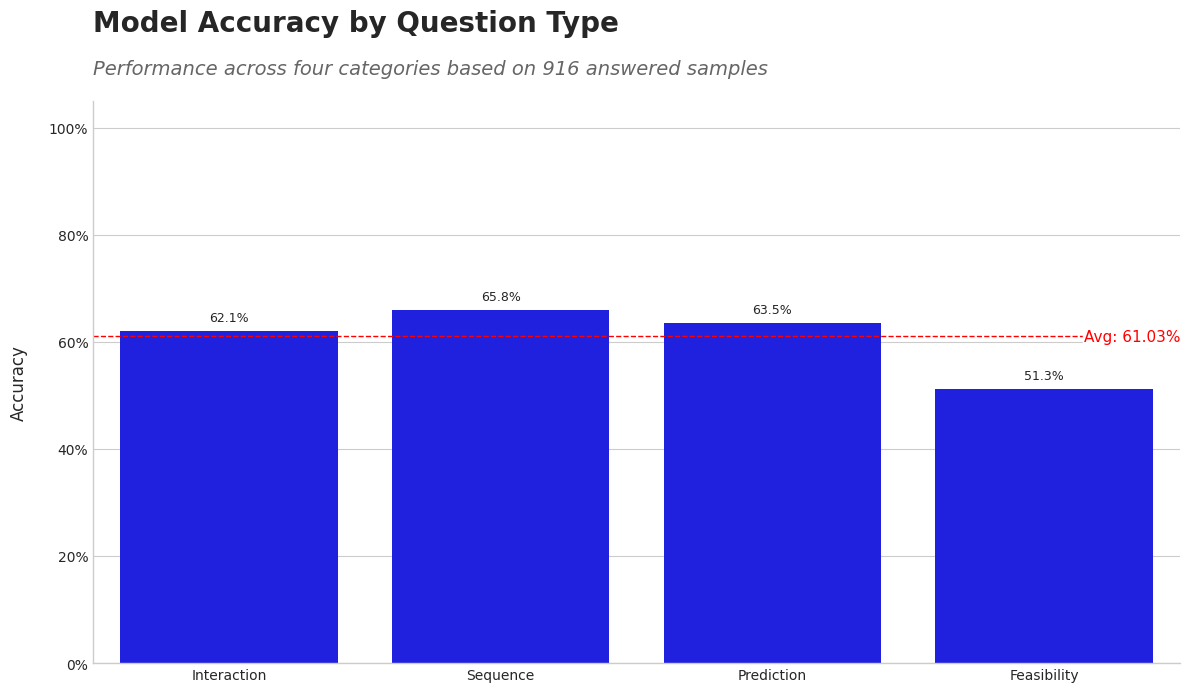

In [35]:
rp.plot_acc(gemma_eval_df[gemma_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


In [36]:
rp.print_ans_perc(gemma_eval_df[gemma_eval_df['contains_answer']], gemma_pred_gg_df)


Question type       Total      Answered 

Interaction          297        93.27%  
Sequence             285        85.26%  
Prediction           232        84.91%  
Feasibility          218        91.28%  
Overall             1032        88.76%  


/home/lusha/star_code/src/response_processing.py:528: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


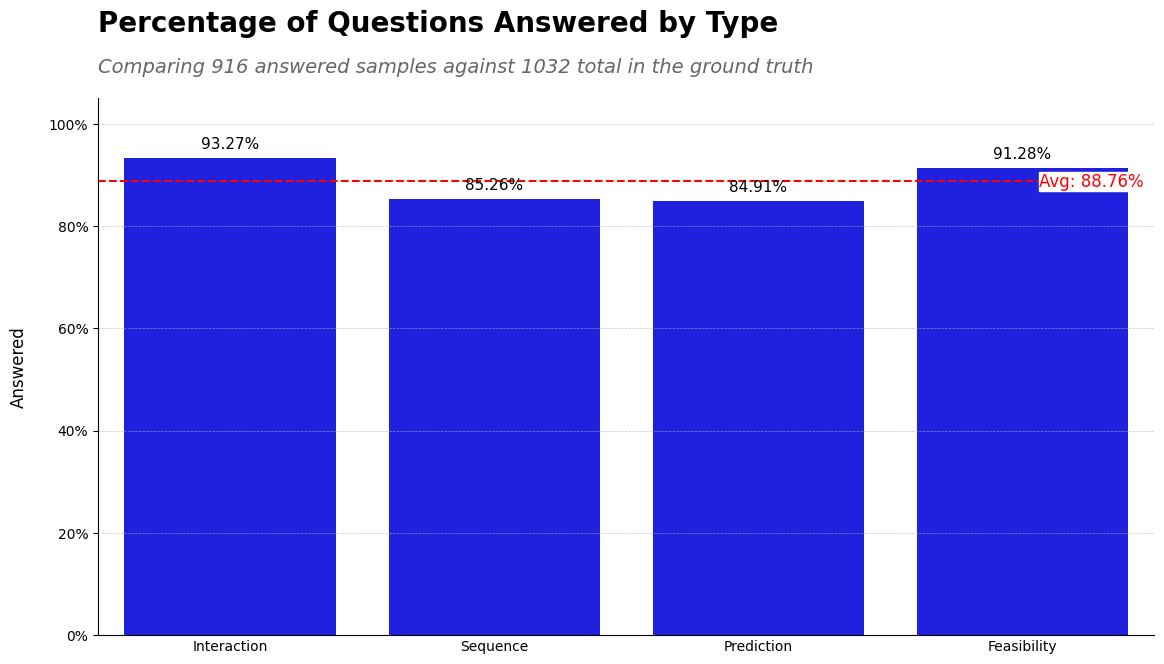

In [37]:
rp.plot_ans_perc(gemma_eval_df[gemma_eval_df['contains_answer']], gemma_pred_gg_df)


## Gemini

In [38]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemini_eval_df = gt_df.join(
    gemini_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemini_eval_df[gemini_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))
print("\nAccounting for missing answers:")
rp.print_acc(gemini_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          260        70.77%  
Sequence             241        73.44%  
Prediction           193        63.73%  
Feasibility          191        56.02%  

Average              885        66.78%  

Accounting for missing answers:
Question type       Total      Accuracy 

Interaction          296        62.16%  
Sequence             285        62.11%  
Prediction           232        53.02%  
Feasibility          218        49.08%  

Average             1031        57.32%  


/home/lusha/star_code/src/response_processing.py:450: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


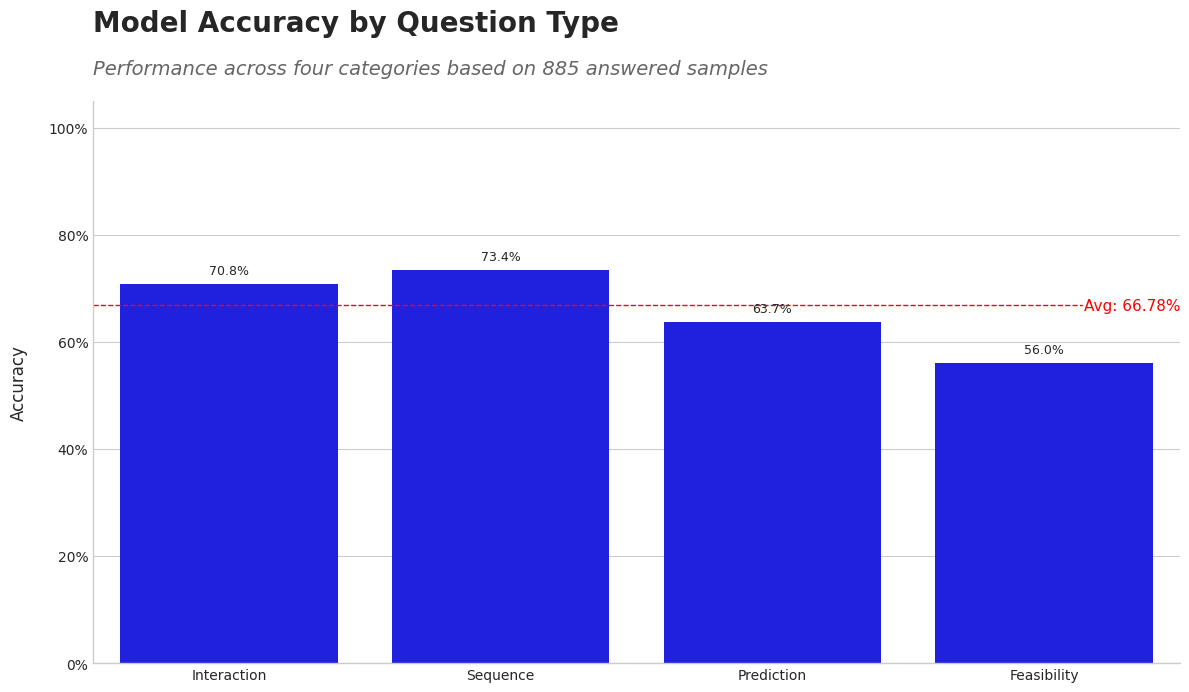

In [39]:
rp.plot_acc(gemini_eval_df[gemini_eval_df['contains_answer']], lambda x: rp.accuracy(x, on_what='text'))


In [40]:
rp.print_ans_perc(gemini_eval_df.loc[gemini_eval_df['contains_answer']], gemini_pred_gg_df)


Question type       Total      Answered 

Interaction          296        87.84%  
Sequence             285        84.56%  
Prediction           232        83.19%  
Feasibility          218        87.61%  
Overall             1031        85.84%  


/home/lusha/star_code/src/response_processing.py:528: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.text(


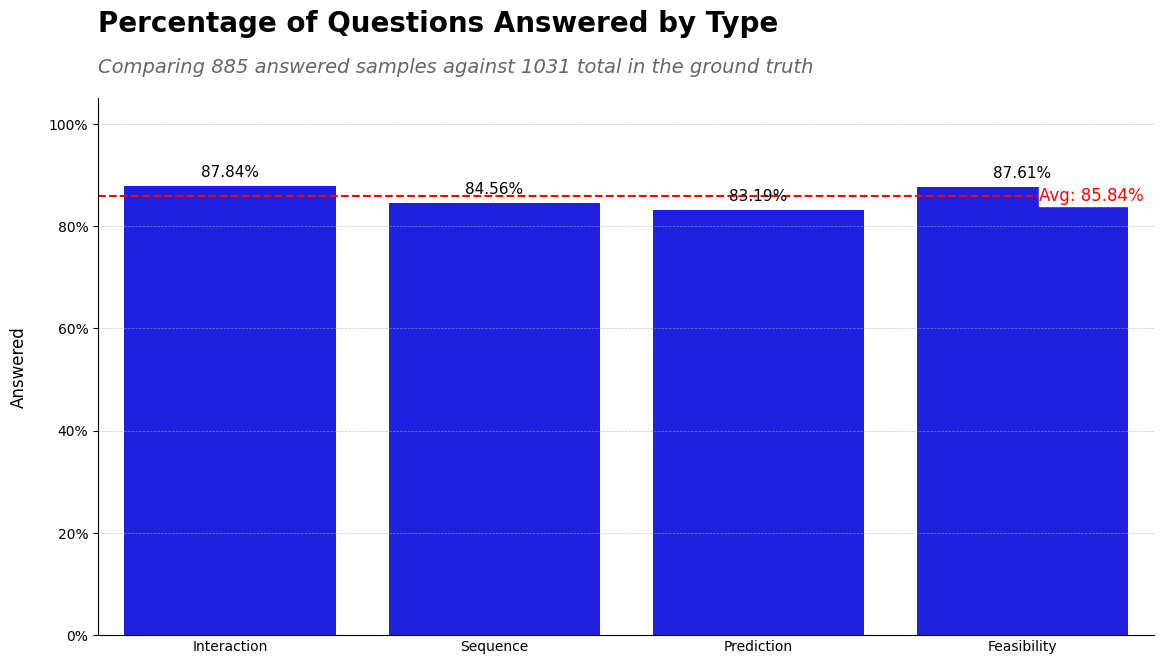

In [41]:
rp.plot_ans_perc(gemini_eval_df.loc[gemini_eval_df['contains_answer']], gemini_pred_gg_df)


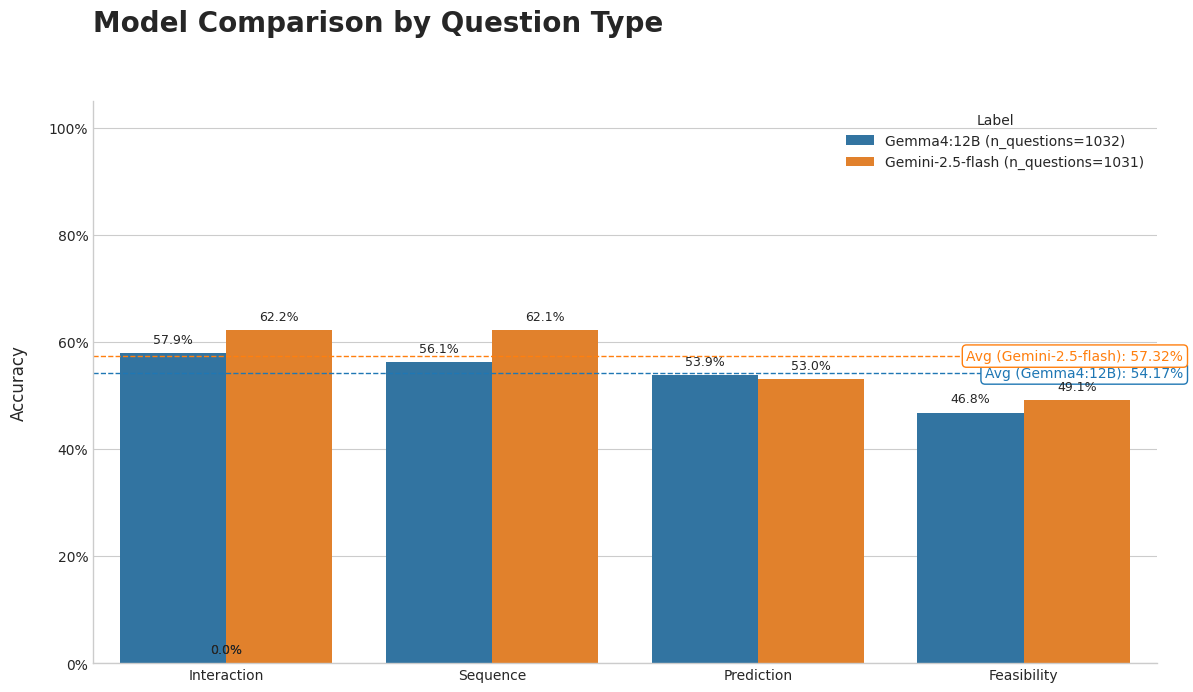

In [42]:
rp.plot_acc([gemma_eval_df, gemini_eval_df], labels=['Gemma4:12B', "Gemini-2.5-flash"], acc_fn=lambda x: rp.accuracy(x, on_what='text'))


# Combining

In [43]:
eval_df_all = (
    gt_df
    .join(
        gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']]\
        .rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
        how='inner'
    ).join(
        gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']]\
        .rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
        how='inner'
    )
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
id,,,,
Feasibility_T5_102,Which object is the person able to throw after...,the clothes.,the clothes.,the clothes.
Feasibility_T5_1851,Which object is the person able to close after...,the laptop.,the book.,the book.
Prediction_T2_450,What will the person do next with the clothes?,take.,take.,put down.
Feasibility_T5_1670,Which object is the person able to hold after ...,the dish.,the shoe.,the dish.
Sequence_T5_4571,What did the person do to the clothes after si...,put down.,tidied up.,tidied up.
...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,the dish.,the dish.,the food.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,put down.,put down.


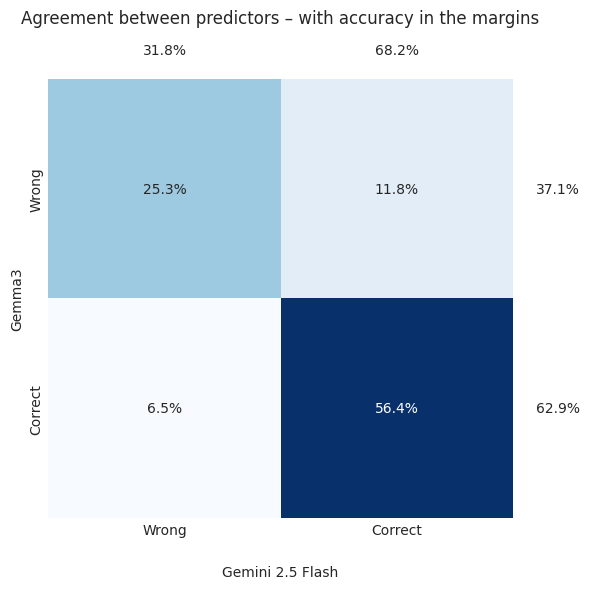

(821, 10)


In [44]:
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


### Why is the accuracy with the generated SG as base so low?

In [45]:
answered_questions = [idx for idx in gemini_eval_df.index if idx in prev_analyzed]
answered_questions


['Interaction_T1_4115',
 'Interaction_T1_4221',
 'Interaction_T1_111',
 'Interaction_T1_309',
 'Interaction_T1_1168',
 'Interaction_T1_2226',
 'Interaction_T1_2516',
 'Interaction_T1_4054',
 'Interaction_T1_4703',
 'Interaction_T1_5709',
 'Interaction_T1_7254',
 'Interaction_T1_8274',
 'Interaction_T1_8913',
 'Interaction_T1_8967',
 'Interaction_T2_3423']

### Looking at some of the answers

In [46]:
rp.print_acc(gemini_eval_df.loc[answered_questions], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          15         53.33%  
Sequence              0          nan%   
Prediction            0          nan%   
Feasibility           0          nan%   

Average              15         53.33%  


/home/lusha/star_code/src/response_processing.py:295: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]


In [47]:
correct_idx = (gemini_eval_df.loc[answered_questions, 'text'] == gemini_eval_df.loc[answered_questions, 'pred_text'])
correct_idx =  correct_idx[correct_idx].index.to_list()
correct_idx


['Interaction_T1_4115',
 'Interaction_T1_4221',
 'Interaction_T1_111',
 'Interaction_T1_1168',
 'Interaction_T1_2516',
 'Interaction_T1_4703',
 'Interaction_T1_8274',
 'Interaction_T1_8913']

In [48]:
wrong_idx = (gemini_eval_df.loc[answered_questions, 'text'] != gemini_eval_df.loc[answered_questions, 'pred_text'])
wrong_idx = wrong_idx[wrong_idx].index.to_list()
wrong_idx


['Interaction_T1_309',
 'Interaction_T1_2226',
 'Interaction_T1_4054',
 'Interaction_T1_5709',
 'Interaction_T1_7254',
 'Interaction_T1_8967',
 'Interaction_T2_3423']

<Axes: xlabel='stsg', ylabel='Count'>

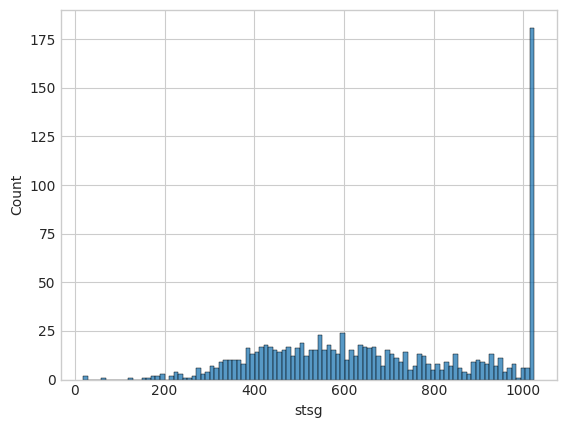

In [49]:
hugg_auth_token = os.environ.get("HUGGINGFACE_KEY")
gemma3_tokenizer = AutoTokenizer.from_pretrained(
    "google/gemma-3-4b-it",
    token=hugg_auth_token
)

sgg_token_len = sgg_df['stsg'].apply(lambda x: len(gemma3_tokenizer.tokenize(x)))

sns.histplot(sgg_token_len, bins=100)


## Inspection - 1
Check why Gemini doesn't answer some on the questions

### Sample

In [ ]:
idx = "Interaction_T1_1168"


In [156]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Interaction_T1_1168 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The phone/camera.
│    1. The food.
│    2. The laptop.
│    3. The bag.
│
│ Ground Truth:
│    The phone/camera.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        The phone/camera. [CORRECT]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify which object the person took or began to manipulate, based on the changes observed in the Spatio-Temporal Scene Graph.
│        
│        2. **STSG Analysis:**
│            *   **Frame 0:** The person is holding a "reddish-purple_object".
│            *   **Frame 1:** The person is "manipulating" a "dark_object". Importantly, "hands" are also "manipulating" this "dark_object". The "reddish-purple_object" is no longer explicitly mentioned as being held or present.
│            *   **Frame 2:** The person is once aga

In [157]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][0]['content'])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- sitting_on ---- bed
person ---- wearing ---- glasses
person ---- wearing ---- green_hooded_sweatshirt
person ---- holding ---- reddish-purple_object
dog ---- beside ---- person
dog ---- sitting_on ---- bed
dog ---- to_the_left_of ---- person
dresser ---- to_the_left_of ---- person
window ---- behind ---- person
glare ---- from ---- window
</scene_graph>

Frame 1:
<scene_graph>
person ---- sitting_on ---- bed
person ---- wearing ---- glasses
person ---- wearing ---- green_hooded_sweatshirt
person ---- manipulating ---- dark_object
hands ---- manipulating ---- dark_object
dog ---- beside ---- person
dog ---- sitting_on ---- bed
dog ---- to_the_left_of ---- person
dresser ---- to_the_left_of ---- person
window ---- behind ---- person
glare ---- from ---- window
</scene_graph>

Frame 2:
<scene_graph>
per

In [158]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][1]['content'])



1. **Question Interpretation:** The question asks to identify which object the person took or began to manipulate, based on the changes observed in the Spatio-Temporal Scene Graph.

2. **STSG Analysis:**
    *   **Frame 0:** The person is holding a "reddish-purple_object".
    *   **Frame 1:** The person is "manipulating" a "dark_object". Importantly, "hands" are also "manipulating" this "dark_object". The "reddish-purple_object" is no longer explicitly mentioned as being held or present.
    *   **Frame 2:** The person is once again "holding" the "reddish-purple_object".

3. **Alternative Evaluation:**

    *   **A. The phone/camera:** The STSG mentions a "dark_object" being manipulated by the person and their hands in Frame 1. A phone or camera could be a dark object. This is a plausible candidate for the object that was "taken" or engaged with.
    *   **B. The food:** There is no mention of "food" in any of the frames.
    *   **C. The laptop:** There is no mention of a "laptop" i

In [159]:
print(gemini_pred_gg_df.loc[idx]['chat_history'][3]['content'])



```json
{"answer": "A. The phone/camera."}
```


#### Gemma

In [160]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- sitting_on ---- bed
person ---- wearing ---- glasses
person ---- wearing ---- green_hooded_sweatshirt
person ---- holding ---- reddish-purple_object
dog ---- beside ---- person
dog ---- sitting_on ---- bed
dog ---- to_the_left_of ---- person
dresser ---- to_the_left_of ---- person
window ---- behind ---- person
glare ---- from ---- window
</scene_graph>

Frame 1:
<scene_graph>
person ---- sitting_on ---- bed
person ---- wearing ---- glasses
person ---- wearing ---- green_hooded_sweatshirt
person ---- manipulating ---- dark_object
hands ---- manipulating ---- dark_object
dog ---- beside ---- person
dog ---- sitting_on ---- bed
dog ---- to_the_left_of ---- person
dresser ---- to_the_left_of ---- person
window ---- behind ---- person
glare ---- from ---- window
</scene_graph>

Frame 2:
<scene_graph>
pers

In [ ]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemma_pred_gg_df.rename(columns={'answer': 'pred_text'})])



┌─ Sample: Interaction_T1_1168 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The phone/camera.
│    1. The food.
│    2. The laptop.
│    3. The bag.
│
│ Ground Truth:
│    The phone/camera.
│
│
│ Model Predictions - Prediction 1:
│    Prediction:
│        The phone/camera. [CORRECT]
│    Reasoning:
│        Okay, let's break down this question and the provided STSG to determine which object the person took.
│        
│        **1. Question Interpretation:**
│        
│        The question asks us to identify an object that the person "took" from the scene. In the context of the STSG, "took" implies a change in possession or interaction with an object between frames. We need to look for an object that appears in one frame and then disappears or is being manipulated differently in a subsequent frame.
│        
│        **2. STSG Analysis:**
│        
│        *   **Frame 0:** The person is 

In [162]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][1]['content'])


Okay, let's break down this question and the provided STSG to determine which object the person took.

**1. Question Interpretation:**

The question asks us to identify an object that the person "took" from the scene. In the context of the STSG, "took" implies a change in possession or interaction with an object between frames. We need to look for an object that appears in one frame and then disappears or is being manipulated differently in a subsequent frame.

**2. STSG Analysis:**

*   **Frame 0:** The person is holding a "reddish-purple\_object."
*   **Frame 1:** The person is "manipulating" a "dark\_object," and their "hands" are also manipulating the "dark\_object." This indicates a change in the object being interacted with.
*   **Frame 2:** The person is again holding the "reddish-purple\_object." This returns the scene to the initial state.

**3. Alternative Evaluation:**

*   **A. The phone/camera:** The STSG mentions a "dark\_object" being manipulated. A phone or camera could

In [163]:
print(gemma_pred_gg_df.loc[idx]['chat_history'][3]['content'])


{"answer": "A. The phone/camera."}



In [164]:
gemma_eval_df.loc[idx]


question                        Which object was taken by the person?
video_id                                                        E7GV1
start                                                             0.0
end                                                               3.1
text                                                The phone/camera.
question_program    [{'function': 'Situations', 'value_input': []}...
choices             [{'choice_id': 0, 'choice': 'The phone/camera....
situations          {'000010': {'rel_pairs': [['o000', 'o014'], ['...
chat_history        [{'role': 'user', 'content': 'Please carefully...
contains_answer                                                  True
pred_text                                           The phone/camera.
Name: Interaction_T1_1168, dtype: object

#### Inspect frames

In [165]:
SHOW_VIDEO = True


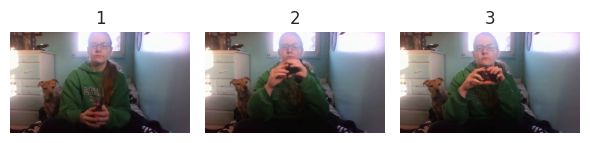

In [166]:
import math

frames_per_row = 3

if SHOW_VIDEO:
    video_path = RAW_VIDEO_DIR / f"{gt_df.loc[idx]['video_id']}.mp4"
    start = gt_df.loc[idx]['start']
    end = gt_df.loc[idx]['end']
    # values used in the experiments
    fps = 1
    max_frames = 64

    frame_dir, frame_paths = video_tools.extract_frames(
        video_path,
        fps=fps,
        max_frames=max_frames,
        start_time=start,
        end_time=end,
    )
    
    frames_per_row = min(frames_per_row, len(frame_paths))
    rows = math.ceil(len(frame_paths) / frames_per_row)
    
    images = frame_paths
    fig, axes = plt.subplots(rows, frames_per_row, figsize=(6*rows, 3*frames_per_row))
    axes = axes.flatten()
    
    for i, img_path in enumerate(images):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(f"{i+1}")
        axes[i].axis('off')
    
    # Turn off the axes for any remaining subplots
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()


In [167]:
print(sgg_df.loc[idx]['stsg'])


<stsg>
Frame 0:
<scene_graph>
person ---- sitting_on ---- bed
person ---- wearing ---- glasses
person ---- wearing ---- green_hooded_sweatshirt
person ---- holding ---- reddish-purple_object
dog ---- beside ---- person
dog ---- sitting_on ---- bed
dog ---- to_the_left_of ---- person
dresser ---- to_the_left_of ---- person
window ---- behind ---- person
glare ---- from ---- window
</scene_graph>

Frame 1:
<scene_graph>
person ---- sitting_on ---- bed
person ---- wearing ---- glasses
person ---- wearing ---- green_hooded_sweatshirt
person ---- manipulating ---- dark_object
hands ---- manipulating ---- dark_object
dog ---- beside ---- person
dog ---- sitting_on ---- bed
dog ---- to_the_left_of ---- person
dresser ---- to_the_left_of ---- person
window ---- behind ---- person
glare ---- from ---- window
</scene_graph>

Frame 2:
<scene_graph>
person ---- sitting_on ---- bed
person ---- wearing ---- glasses
person ---- wearing ---- green_hooded_sweatshirt
person ---- holding ---- reddish-pur

#### Inspect the video

In [168]:

if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


	Video Seg:  0.0s - 3.1s


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab